<a href="https://colab.research.google.com/github/stsyaakirah/Brain-Tumor-Detection-Using-Convolutional-Neural-Network/blob/master/Brain_Tumor_Modeling_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Classification - Model Training Notebook

Berdasarkan hasil Exploratory Data Analysis (EDA) sebelumnya, kita akan melakukan preprocessing data tingkat lanjut (CLAHE & Padding) sebelum memasukkannya ke dalam Model *Convolutional Neural Network* (CNN).

Notebook ini dirancang khusus untuk dijalankan di **Google Colab** dengan pemanfaatan GPU.

In [50]:
import os
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from glob import glob

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Input, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Memastikan TensorFlow mendeteksi GPU di Google Colab
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


## 1. Physical Data Preprocessing: CLAHE & Zero Padding
Fungsi ini membaca gambar mentah (`brain_tumor_dataset`), melakukan pemerataan kontras cahaya (CLAHE), menambahkan padding agar gambar menjadi persegi panjang sempurna 224x224 (tanpa distorsi), lalu menyimpannya ke folder baru bernama `dataset_processed`. Proses ini cukup dijalankan **satu kali saja**.

In [51]:
import os
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from glob import glob

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Input, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Memastikan TensorFlow mendeteksi GPU di Google Colab
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Path Dataset (Sesuaikan dengan lokasi di Google Drive / Local jika berbeda)
RAW_DATA_PATH = 'Brain-Tumor-Detection-Using-Convolutional-Neural-Network/brain_tumor_dataset'
PROCESSED_DATA_PATH = 'dataset_processed'
CLASSES = ['no', 'yes']
TARGET_SIZE = 224

def resize_with_pad(img_cv2, expected_size):
    ''' Mengubah ukuran rasio OpenCV ke persegi dengan pad hitam '''
    old_size = img_cv2.shape[:2]
    ratio = float(expected_size) / max(old_size)
    new_size = tuple([int(x * ratio) for x in old_size])

    # Resize sesuai rasio
    img_resized = cv2.resize(img_cv2, (new_size[1], new_size[0]), interpolation=cv2.INTER_LANCZOS4)

    # Buat kanvas hitam (Zero Padding)
    delta_w = expected_size - new_size[1]
    delta_h = expected_size - new_size[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)

    color = [0, 0, 0]
    img_padded = cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return img_padded

# Eksekusi Transformasi Massal
if not os.path.exists(PROCESSED_DATA_PATH):
    os.makedirs(PROCESSED_DATA_PATH)

    for cl in CLASSES:
        os.makedirs(os.path.join(PROCESSED_DATA_PATH, cl), exist_ok=True)
        img_paths = glob(os.path.join(RAW_DATA_PATH, cl, '*'))

        print(f"Memproses folder '{cl}'... ({len(img_paths)} gambar)")
        for path in tqdm(img_paths):
            filename = os.path.basename(path)
            # Membaca sebagai Grayscale dulu karena MRI umumnya hitam putih
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue

            # 1. Terapkan CLAHE untuk perbaikan kontras
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img_clahe = clahe.apply(img)

            # Convert kembali ke BGR (3 Channel) yang diminta oleh kebanyakan model Transfer Learning CNN
            img_clahe_bgr = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2BGR)

            # 2. Resizing & Padding (Mencegah distorsi memanjang/melebar)
            img_final = resize_with_pad(img_clahe_bgr, TARGET_SIZE)

            # Simpan Data Fisik
            save_path = os.path.join(PROCESSED_DATA_PATH, cl, filename)
            # Ekstensi diubah jadi JPG untuk kepastian
            if not save_path.endswith('.jpg'):
                save_path = save_path.split('.')[0] + '.jpg'

            cv2.imwrite(save_path, img_final)
    print("\nFolder 'dataset_processed' selesai dibuat! Dataset baru sudah matang.")
else:
    print("\nFolder 'dataset_processed' sudah ada. Melewati proses...")

Num GPUs Available:  1
Memproses folder 'no'... (0 gambar)


0it [00:00, ?it/s]


Memproses folder 'yes'... (0 gambar)


0it [00:00, ?it/s]


Folder 'dataset_processed' selesai dibuat! Dataset baru sudah matang.


### 1. Instal Kaggle API Client

In [57]:
!pip install kaggle

### 2. Unggah Kaggle API Key Anda

Untuk mengunduh dataset dari Kaggle, Anda memerlukan API key Anda.

1.  Buka [Kaggle](https://www.kaggle.com/).
2.  Klik ikon profil Anda di kanan atas, lalu pilih "Account".
3.  Gulir ke bawah ke bagian "API", lalu klik "Create New API Token". Ini akan mengunduh file `kaggle.json`.
4.  Di Colab, klik ikon folder (Files) di sisi kiri. Kemudian klik ikon "Upload to session storage" (panah ke atas).
5.  Unggah file `kaggle.json` yang baru saja Anda unduh ke direktori `/content/`.


### 3. Konfigurasi Kaggle dan Unduh Dataset

In [58]:
# Pindahkan kaggle.json ke direktori yang benar dan setel izin
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Unduh dataset
# Dataset: navoneel/brain-mri-images-for-brain-tumor-detection
# Ini akan mengunduh file ZIP ke direktori saat ini (/content/)
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:00<00:00, 134MB/s]



### 4. Ekstrak Dataset

In [59]:
# Ekstrak file ZIP yang diunduh
# Pastikan nama file ZIP sesuai dengan yang diunduh dari Kaggle
!unzip -q brain-mri-images-for-brain-tumor-detection.zip -d brain_tumor_detection_kaggle

print("Dataset berhasil diunduh dan diekstrak ke folder 'brain_tumor_detection_kaggle'!")

Dataset berhasil diunduh dan diekstrak ke folder 'brain_tumor_detection_kaggle'!


### 5. Perbarui `RAW_DATA_PATH` dan Jalankan Kembali Preprocessing

Setelah dataset berhasil diunduh dan diekstrak, Anda perlu memperbarui variabel `RAW_DATA_PATH` di sel preprocessing (`25f9318a`) agar menunjuk ke folder dataset yang benar. Kemudian, hapus folder `dataset_processed` (jika ada) dan jalankan kembali sel preprocessing.

In [60]:
# Hapus folder dataset_processed yang sudah ada agar data baru dapat diproses
import shutil
import os

PROCESSED_DATA_PATH = 'dataset_processed'

if os.path.exists(PROCESSED_DATA_PATH):
    shutil.rmtree(PROCESSED_DATA_PATH)
    print(f"Folder '{PROCESSED_DATA_PATH}' telah dihapus.")
else:
    print(f"Folder '{PROCESSED_DATA_PATH}' tidak ditemukan.")

Folder 'dataset_processed' telah dihapus.


In [61]:
import os
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from glob import glob

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Input, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Memastikan TensorFlow mendeteksi GPU di Google Colab
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Path Dataset (Sesuaikan dengan lokasi di Google Drive / Local jika berbeda)
RAW_DATA_PATH = 'brain_tumor_detection_kaggle/brain_tumor_dataset'
PROCESSED_DATA_PATH = 'dataset_processed'
CLASSES = ['no', 'yes']
TARGET_SIZE = 224

def resize_with_pad(img_cv2, expected_size):
    ''' Mengubah ukuran rasio OpenCV ke persegi dengan pad hitam '''
    old_size = img_cv2.shape[:2]
    ratio = float(expected_size) / max(old_size)
    new_size = tuple([int(x * ratio) for x in old_size])

    # Resize sesuai rasio
    img_resized = cv2.resize(img_cv2, (new_size[1], new_size[0]), interpolation=cv2.INTER_LANCZOS4)

    # Buat kanvas hitam (Zero Padding)
    delta_w = expected_size - new_size[1]
    delta_h = expected_size - new_size[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)

    color = [0, 0, 0]
    img_padded = cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return img_padded

# Eksekusi Transformasi Massal
if not os.path.exists(PROCESSED_DATA_PATH):
    os.makedirs(PROCESSED_DATA_PATH)

    for cl in CLASSES:
        os.makedirs(os.path.join(PROCESSED_DATA_PATH, cl), exist_ok=True)
        img_paths = glob(os.path.join(RAW_DATA_PATH, cl, '*'))

        print(f"Memproses folder '{cl}'... ({len(img_paths)} gambar)")
        for path in tqdm(img_paths):
            filename = os.path.basename(path)
            # Membaca sebagai Grayscale dulu karena MRI umumnya hitam putih
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue

            # 1. Terapkan CLAHE untuk perbaikan kontras
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img_clahe = clahe.apply(img)

            # Convert kembali ke BGR (3 Channel) yang diminta oleh kebanyakan model Transfer Learning CNN
            img_clahe_bgr = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2BGR)

            # 2. Resizing & Padding (Mencegah distorsi memanjang/melebar)
            img_final = resize_with_pad(img_clahe_bgr, TARGET_SIZE)

            # Simpan Data Fisik
            save_path = os.path.join(PROCESSED_DATA_PATH, cl, filename)
            # Ekstensi diubah jadi JPG untuk kepastian
            if not save_path.endswith('.jpg'):
                save_path = save_path.split('.')[0] + '.jpg'

            cv2.imwrite(save_path, img_final)
    print("\nFolder 'dataset_processed' selesai dibuat! Dataset baru sudah matang.")
else:
    print("\nFolder 'dataset_processed' sudah ada. Melewati proses...")

Num GPUs Available:  1
Memproses folder 'no'... (98 gambar)


100%|██████████| 98/98 [00:00<00:00, 195.73it/s]


Memproses folder 'yes'... (155 gambar)


100%|██████████| 155/155 [00:00<00:00, 218.73it/s]


Folder 'dataset_processed' selesai dibuat! Dataset baru sudah matang.


## 2. Keras ImageDataGenerator (Augmentasi Data Ideal)
Sekarang kita konfigurasikan `ImageDataGenerator` untuk mengambil data lansung dari `dataset_processed`. Sesuai _insight_ EDA, kita hanya menerapkan sedikit simulasi augmentasi natural seperti memiringkan (*tilt*) otak sedikit tanpa menarik melar (*shear*).

In [63]:
BATCH_SIZE = 32

# Generator Train (Data Augmentation Diformulasikan secara ideal untuk gambar medis MRI)
train_datagen = ImageDataGenerator(
    rescale=1./255,               # Standar normalisasi agar rentang pixel 0-1
    rotation_range=10,            # Rotasi 10 derajat lazim dengan kelurusan posisi pasien di mesin MRI
    width_shift_range=0.1,        # Geser maksimum 10%
    height_shift_range=0.1,
    zoom_range=0.1,               # Zoom tak boleh berlebih agar tumor tak tercrop ke luar bingkai
    horizontal_flip=True,         # Flip kanan kiri otak diperbolehkan (simetris)
    validation_split=0.2          # 80% Training, 20% Validation
)

# Generator untuk Validation (TIDAK BOLEH DIAUGMENTASI!)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    PROCESSED_DATA_PATH,
    target_size=(TARGET_SIZE, TARGET_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',          # Binary karena Yes vs No
    subset='training',
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    PROCESSED_DATA_PATH,
    target_size=(TARGET_SIZE, TARGET_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42,
    shuffle=False                 # WAJIB FALSE agar evaluasi metrik akhir berurutan akurat
)

Found 203 images belonging to 2 classes.
Found 49 images belonging to 2 classes.


## 3. Pembangunan Arsitektur Model CNN
Karena dataset ini jumlah sampel aslinya relatif terbatas (~250 gambar), kita akan menggunakan Custom CNN dipadukan lapisan `BatchNormalization` dan `Dropout` ekstrem menghindari *Overfitting* akibat data yang sedikit.

In [64]:
model = Sequential([
    Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),

    # Convolutional Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolutional Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolutional Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten to Fully Connected Network
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sigmoid untuk klasifikasi Biner (Yes/No Tumor)
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,784,769 (98.36 MB)

 Trainable params: 25,784,321 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 4. Melatih Model (Training Phase)
Kita terapkan _EarlyStopping_ otomatis. Prosesnya akan berhenti begitu parameter loss pada validation mulai naik (*overfitting*).

In [65]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

EPOCHS = 35

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5961 - loss: 35.5419 - val_accuracy: 0.6939 - val_loss: 0.7201 - learning_rate: 0.0010
Epoch 2/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 347ms/step - accuracy: 0.6256 - loss: 13.2795 - val_accuracy: 0.4898 - val_loss: 2.9341 - learning_rate: 0.0010
Epoch 3/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 347ms/step - accuracy: 0.6749 - loss: 10.5314 - val_accuracy: 0.4898 - val_loss: 7.7838 - learning_rate: 0.0010
Epoch 4/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.5681 - loss: 9.4771
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 525ms/step - accuracy: 0.6158 - loss: 8.0054 - val_accuracy: 0.4898 - val_loss: 10.5678 - learning_rate: 0.0010
Epoch 5/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 362ms/step - accuracy: 0.6946 - loss: 3.4617 - val_accuracy: 0.4898 - val_loss: 13.0947 - learning_rate: 5.0000e-04
Epoch 6/35
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.6650 - loss: 2.5816 - val_accu

## 5. Visualisasi Hasil Pelatihan (Loss & Accuracy Plot)

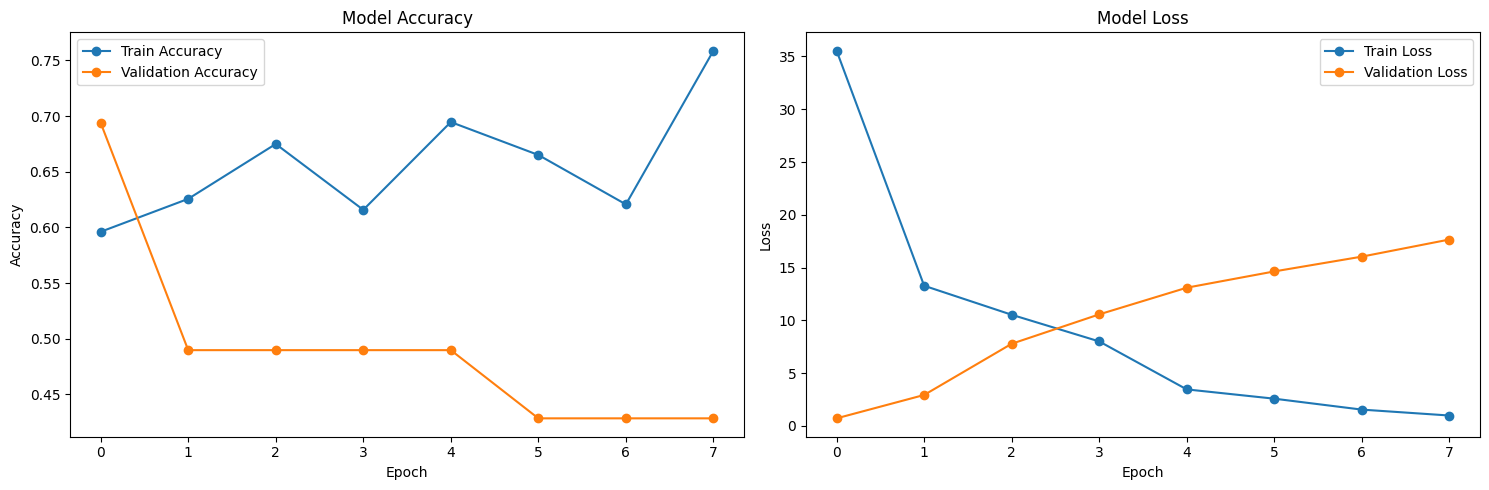

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy Plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss Plot
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluasi Metrik & Confusion Matrix Akhir
Mari kita evaluasi performa model ini pada Test Set (Validation Set yang belum pernah dilihat model di tahapan *training*).

In [67]:
# Reset generator agar selaras prediksi urut
val_generator.reset()

# Melakukan prediksi probabilitas ke data validasi
predictions = model.predict(val_generator)

# Mengonversi probabilitas sigmoid menjadi binar (0 atau 1) dengan threshold 0.5
y_pred = (predictions > 0.5).astype(int)
y_true = val_generator.classes

print("================ CLASSIFICATION REPORT ================")
print(classification_report(y_true, y_pred, target_names=['Normal (No)', 'Tumor (Yes)']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

 Normal (No)       0.67      0.42      0.52        19
 Tumor (Yes)       0.70      0.87      0.78        30

    accuracy                           0.69        49
   macro avg       0.68      0.64      0.65        49
weighted avg       0.69      0.69      0.68        49



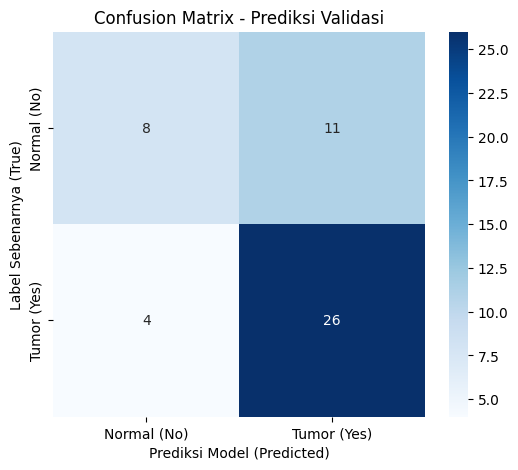

In [68]:
# Menampilkan Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (No)', 'Tumor (Yes)'],
            yticklabels=['Normal (No)', 'Tumor (Yes)'])
plt.title('Confusion Matrix - Prediksi Validasi')
plt.ylabel('Label Sebenarnya (True)')
plt.xlabel('Prediksi Model (Predicted)')
plt.show()